# BB84 Quantum Key Distribution Protocol
## Implementation and Security Analysis with Qiskit

This notebook presents a complete implementation of the BB84 protocol, the first quantum cryptography protocol ever proposed. We demonstrate both the basic protocol and analyze its security against eavesdropping attacks.

### Document Structure

1. **Overview** - Introduction to the BB84 protocol
2. **Part 1: Quantum Mechanical Foundations** - Essential quantum concepts
   - Qubits and quantum states
   - Measurement bases (Z and X)
3. **Part 2: Protocol Implementation** - Step-by-step implementation
   - Alice's preparation
   - Bob's measurement
   - Classical post-processing
4. **Part 3: Complete Protocol Execution** - Demonstration without attacks
   - Secure key exchange results
5. **Part 4: Security Analysis** - Why BB84 is secure
   - Eve's attack strategy
   - Detection mechanism
6. **Part 5: Protocol with Eavesdropping** - Practical demonstration of attack detection

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
import numpy as np

## Overview

The BB84 protocol is a "prepare and measure" Quantum Key Distribution (QKD) protocol created by Charles Bennett and Gilles Brassard in 1984. As the first quantum cryptography protocol ever proposed, it established the foundational framework for theoretically secure key exchange. It remains the standard paradigm and the most famous QKD protocol in the field.

## Part 1: Quantum Mechanical Foundations

### 1.1 Introduction to Qubits and Quantum States

To start, we have to introduce some quantum concepts. The first thing is to introduce the qubit and its states.

A quantum state $|\psi \rangle$ is a mathematical object that describes a quantum system. The easiest quantum system to describe is a two-level system, a qubit.

A classical bit is also a two-level system with possible states 0 and 1. Analogously, a qubit also has two levels: $|0 \rangle$ and $|1 \rangle$. 

What is different—and what makes the "quantum magic" happen—is that a qubit can be in $|0 \rangle$, $|1 \rangle$, or any normalized linear combination of them. For example:

$$
|\psi \rangle=\sqrt{\frac{5}{6}}|0 \rangle+\sqrt{\frac{1}{6}}|1 \rangle
$$
This is what we call superposition. The coefficients are generally complex numbers and are restricted so that the sum of their modulus squared equals 1. This normalization condition is required for valid quantum states.

We can move arbitrarily between different superpositions using operators (gates) $U$, with the only restriction that they must keep the states normalized.

Finally, in the real world we cannot measure superpositions directly; we can only obtain either 0 or 1. If a state is in superposition, the probability of each outcome is the modulus squared of its coefficient (in our example, 5/6 probability of obtaining 0 and 1/6 probability of obtaining 1). This is why states must be normalized. Also, the qubit is destroyed during measurement.

### 1.2 Measurement Bases: Z and X

After this theoretical introduction, we specify which states we will use in our protocol. We will work with the computational basis states $|0 \rangle$, $|1 \rangle$ and the Hadamard basis states $|+ \rangle$ and $|- \rangle$, defined as:

$$
|+ \rangle=H|0 \rangle=\frac{1}{\sqrt{2}}\left( |0 \rangle + |1 \rangle \right) \qquad 
|- \rangle=H|1 \rangle=\frac{1}{\sqrt{2}}\left( |0 \rangle - |1 \rangle \right)
$$

where $H$ is the Hadamard gate. It is important to note that:

$$
|0 \rangle=H|+ \rangle\qquad 
|1 \rangle=H|- \rangle
$$

This means the transformation is reversible by applying the Hadamard gate again.

Now let us introduce the standard terminology.

If Alice prepares a qubit representing a 0 in the state $|0 \rangle$, we say "Alice prepared 0 in the Z basis". If she applies a Hadamard gate before sending the qubit, it becomes $|+ \rangle=H|0 \rangle$, and we say "Alice prepared 0 in the X basis". The same terminology applies for 1, encoded in states $|1 \rangle$ and $|- \rangle$ respectively.

When the qubit arrives at Bob, he can measure it directly ("Bob measures in Z") or apply a Hadamard gate before measurement ("Bob measures in X"). Although this terminology may seem unusual for beginners, it is standard in quantum computing and rooted in quantum theory.

Finally, a crucial property for the protocol's security is that a qubit cannot be cloned—this is the "no-cloning theorem".

## Part 2: Protocol Implementation

### 2.1 Alice's Step - Bit Generation and Preparation

Now we are ready to implement the protocol. The first step is to generate the bits that will be sent. This is done classically using NumPy.

In [2]:
def alice_bit_generation(n_bits):
    alice_bits= np.random.randint(0,2,size=n_bits,dtype='int8') 
    return alice_bits       

#### Alice's Qubit Preparation

The next step is to convert bits into qubits. Since Qiskit works with quantum circuits, we represent individual qubits as single-qubit circuits. The encoding is done with the following code:
- Bit value determines the X gate (1 → apply X gate)
- Random basis choice determines the H gate (X basis → apply H gate)

In [3]:
def alice_prepare_qubits(alice_bits):
    n_bits=len(alice_bits)
    alice_basis= np.random.randint(0,2,size=n_bits,dtype='int8') #0 == Basis Z ; 1== Basis X         

    qubits=[] #Empty list to store the qubits

    for i in range(n_bits):

        qc=QuantumCircuit(1) #We initialize the qubit, by default at |0>

        if alice_bits[i]: #This executes if the classical bit is a 1
            qc.x(qubit=0) #Add an X gate,this changes |0> to |1>
        
        if alice_basis[i]:#This executes is the chosen basis is X
            qc.h(qubit=0) #Add an H gate, we change basis to X

        qc.barrier() #We add a barrier to represent the sending
        qubits.append(qc)
    return qubits,alice_basis


### 2.2 Bob's Step - Measurement

Alice has sent her qubits to Bob. Now Bob's first step is to randomly choose a measurement basis for each qubit received.

#### Quantum Measurement Simulation

Next, we implement Bob's measurement using Qiskit's simulator with optional noise modeling.

In [4]:
#Qiskit have different templates to noise model, max number of qubits of a circuit, available gates...
#This are fake providers
def bob_measures(qubits,noise_model=None):

    bob_basis=np.random.randint(0,2,size=n_bits,dtype='int8') #Bob generates his basis

    for i in range(n_bits):
        if bob_basis[i]: #If Bob measures in X basis we have to add an H
            qubits[i].h(0) 
        qubits[i].measure_all() #Instruction to measure the qubits of a circuit

    backend=FakeVigoV2() #We choose our template, other fake providers exist
    simulator=AerSimulator.from_backend(backend) #This is the actual simulator initialized from our backend
    qubits_t=transpile(qubits,backend) #This adapts the circuit to the chosen backend

    #noise_model= None or True depending if we want to simulate noise


    #We execute the simulation, Qiskit works with lists and arrays by default
    if noise_model:
        job=simulator.run(qubits_t,shots=1)
    else:
        job=simulator.run(qubits_t,noise_model=None,shots=1)

    #We extract the results
    results=job.result()

    #We extract the value of the count
    counts=results.get_counts() #This is a dictionary of how many 0's and 1's

    #We convert from the list of dictionaries to a bitstring (array of 0's and 1's)
    bob_bits = np.array([int(list(out.keys())[0]) for out in counts])
    return bob_bits,bob_basis

### 2.3 Classical Post-Processing - Base Sifting and Error Detection

#### Matching Bases and Coin Tosses

If Bob chooses the same basis as Alice, the final state will be $|0 \rangle$ or $|1 \rangle$, and the measurement will always yield the correct result. However, if they choose different bases, Bob measures the states $|+ \rangle$ or $|- \rangle$, resulting in a 50-50 coin toss between 0 and 1.

#### Two Essential Steps

The next steps involve classical communication through an authenticated channel and consist of two critical operations:
1. **Base Sifting**: Discard bits with mismatched bases
2. **QBER Calculation**: Detect eavesdropping by calculating the Quantum Bit Error Rate

#### Step 1: Base Sifting

Base sifting consists of discarding bits where Alice and Bob chose different bases, since these cases are coin tosses. Once Bob receives all qubits, he publicly shares his basis with Alice, and Alice shares hers with Bob. This is easily implemented using NumPy arrays.

In [5]:
#We create a boolean mask of True or False depending if their basis coincide 
def public_base_sifting(alice_bits,alice_basis,bob_bits,bob_basis):
    
    same_basis= alice_basis==bob_basis

    #We filter using this mask
    sifted_alice_bits=alice_bits[same_basis]

    sifted_bob_bits=bob_bits[same_basis]
    return sifted_alice_bits,sifted_bob_bits



#### Step 2: QBER Calculation and Eavesdropping Detection

After sifting, Alice and Bob publicly reveal a percentage of the bits (typically 50%) to calculate the QBER metric. This metric measures the percentage of bits that differ after base sifting; ideally, it should be 0. However, this metric provides an estimate of transmission noise and serves as an eavesdropper detector. Again, we implement this using NumPy arrays.

In [ ]:
def public_qber_calculation(sifted_alice_bits,sifted_bob_bits,frac=0.5):
    
    n_sifted_bits = len(sifted_alice_bits)
    n_public_bits = int(n_sifted_bits * frac) #Number of qubits that will be made public

    #We choose randomly the index of the public bits
    public_indexes = np.random.choice(n_sifted_bits,size=n_public_bits,replace=False)

    #Again, we make use of a boolean mask
    public_mask = np.zeros(n_sifted_bits, dtype=bool)
    public_mask[public_indexes] = True



    #We extract the public bits from the mask
    alice_public = sifted_alice_bits[public_mask]
    bob_public = sifted_bob_bits[public_mask]

    # We calculate the errors and the qubits using the public bits
    bit_errors = np.sum(alice_public != bob_public) 
    qber = bit_errors / n_public_bits


    #The remaining bits are the key
    private_mask=~public_mask #private mask= NOT public mask

    remaining_alice_bits = sifted_alice_bits[private_mask]
    remaining_bob_bits = sifted_bob_bits[private_mask]
    return qber,remaining_alice_bits,remaining_bob_bits


## Part 3: Complete Protocol Execution - Without Eavesdropping

### 3.1 Demonstration: Secure Key Exchange

The remaining bits after sifting and testing are the extracted key. Since they are still secret and in an ideal case (no noise, no attack), they would have the same value for both Alice and Bob. Let's execute the complete protocol and verify the results:

A qubit of value 0 prepared by Alice in the basis 0


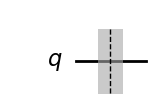

A qubit measured by Bob in the basis 0


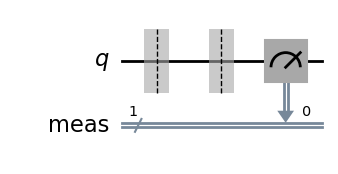

The QBER is 0.019083969465648856
Alice's key is: 
[0 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 1 1
 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0
 0 1 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0
 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0
 1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 0 0 0
 1 1 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0
 0 1 0 0 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1
 0 1 0 0]
Bob's key is
[0 0 0 0 0 0 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 1 1
 1 1 1 1 0 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0
 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0
 0 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0
 1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 0 0 0
 1 1 1 0 1 0 0 1 1 1 0 0 0 

In [7]:
n_bits=1024
noise_model=True

#Alice part
alice_bits=alice_bit_generation(n_bits=n_bits)
qubits,alice_basis=alice_prepare_qubits(alice_bits=alice_bits)

print(f"A qubit of value {alice_bits[14]} prepared by Alice in the basis {alice_basis[14]}")
display(qubits[14].draw("mpl"))

#Bob part 
bob_bits,bob_basis=bob_measures(qubits=qubits,noise_model=noise_model)

print(f"A qubit measured by Bob in the basis {bob_basis[14]}")
display(qubits[14].draw("mpl"))

#Classical public authenticated communication
sifted_alice_bits,sifted_bob_bits=public_base_sifting(alice_bits,alice_basis,
                                                      bob_bits,bob_basis)

qber,alice_key,bob_key=public_qber_calculation(sifted_alice_bits,
                                                  sifted_bob_bits)

#Final result presentation

print(f"The QBER is {qber}")
print("Alice's key is: ")
print(alice_key)
print("Bob's key is")
print(bob_key)
print("Are the same key? ",np.array_equal(alice_key,bob_key))

### 3.2 Observations

If noise is present in the quantum channel, the keys will differ, requiring additional error reconciliation algorithms such as cascade or minnow to correct bit errors. These algorithms are beyond the scope of this notebook. It is also common to perform privacy amplification to achieve arbitrary privacy.

Now the key question arises: **Is this protocol secure against eavesdropping attacks?**

## Part 4: Security Analysis Against Eavesdropping

### 4.1 Introduction to Eve's Attack

This is the fundamental reason for implementing quantum key distribution: it provides theoretical security based on the laws of quantum mechanics.

Let's introduce the attacker Eve and analyze her capabilities and limitations.

Eve's best strategy is to intercept the qubits Alice sends and measure them to recover the bit values. However, two obstacles prevent her success: she cannot clone qubits (as she could with classical bits) due to the no-cloning theorem, and measuring a qubit destroys its state.

Given these constraints, Eve's strategy is to choose a basis, measure the qubit, and resend a new qubit encoded in that basis based on her measurement result. Let us analyze what happens in different scenarios. We assume Alice and Bob chose the same basis (otherwise the qubit is discarded anyway).

### 4.2 Eve's Strategy: Analysis

Two possibilities arise:
1. **50% chance: Eve chooses the same basis as Alice and Bob** 
   - Eve goes unnoticed and extracts the bit value correctly
   
2. **50% chance: Eve chooses a different basis**
   - After Eve's interference, Bob's measurement effectively becomes a coin toss. We analyze two sub-cases:
   
   a) **50% chance: Bob obtains the correct outcome**
      - Eve remains undetected but cannot determine the bit value
   
   b) **50% chance: Bob obtains the wrong outcome**
      - Alice and Bob notice a discrepancy because they should always match. While isolated errors might suggest noise, if Eve intercepts all bits, she causes approximately 50% × 50% = 25% of bits to be incorrect. This raises the QBER to 0.25, far exceeding the standard noise threshold of 0.11. Thus, Alice and Bob can definitively detect Eve's presence and abort the protocol.

### 4.3 Conclusion: Why BB84 is Secure

The security of BB84 relies on the fact that measuring a quantum state disturbs it. Any eavesdropping attempt, no matter how sophisticated, will introduce detectable errors (increased QBER) that allow Alice and Bob to detect the attack.

## Part 5: Protocol Execution - With Eavesdropping

### 5.1 Eve's Attack Implementation

Let us illustrate this eavesdropping scenario with a practical simulation. We implement Eve's attack as follows:

In [ ]:
def eve_attack(alice_qubits):

    n_bits=len(alice_qubits)

    #First Eve chooses her basis randomly 
    eve_basis= np.random.randint(0,2,size=n_bits,dtype='int8')

    #Eve measures the qubits (always without noise)
    for i in range(n_bits):
        if eve_basis[i]: 
            alice_qubits[i].h(0) 
        alice_qubits[i].measure_all() 

    backend=FakeVigoV2() 
    simulator=AerSimulator.from_backend(backend) 
    qubits_t=transpile(qubits,backend) 

    job=simulator.run(qubits_t,noise_model=None,shots=1)
    results=job.result()
    counts=results.get_counts() 
    eve_bits = np.array([int(list(out.keys())[0]) for out in counts])

    #With her outputs and her basis Eve constructs new qubits

    eve_qubits=[]

    for i in range(n_bits):
        qc=QuantumCircuit(1) 
        if eve_bits[i]: 
            qc.x(qubit=0) 
        if eve_basis[i]:
            qc.h(qubit=0) 
        qc.barrier() 
        eve_qubits.append(qc)

    return eve_qubits

### 5.2 Complete Protocol with Eavesdropping

Now we execute the complete protocol with Eve as an active eavesdropper intercepting all qubits. Observe how the QBER will increase significantly, allowing Alice and Bob to detect the attack:

In [9]:
n_bits=1024
noise_model=None
is_there_eve=True

#Alice part
alice_bits=alice_bit_generation(n_bits=n_bits)
qubits,alice_basis=alice_prepare_qubits(alice_bits=alice_bits)


#Eve part
if is_there_eve:
    qubits=eve_attack(alice_qubits=qubits)

#Bob part 
bob_bits,bob_basis=bob_measures(qubits=qubits,noise_model=noise_model)


#Classical public authenticated communication
sifted_alice_bits,sifted_bob_bits=public_base_sifting(alice_bits,alice_basis,
                                                      bob_bits,bob_basis)

qber,alice_key,bob_key=public_qber_calculation(sifted_alice_bits,
                                                  sifted_bob_bits)

#Final result presentation

print(f"The QBER is {qber}")
print("Alice's key is: ")
print(alice_key)
print("Bob's key is")
print(bob_key)
print("Are the same key? ",np.array_equal(alice_key,bob_key))
if qber>0.11:
    print("Attack detected, abort the protocol.")
else:
    print("Proceed with error reconciliation if needed.")

The QBER is 0.25316455696202533
Alice's key is: 
[1 0 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 0 0 1 1
 1 0 1 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 1
 0 1 1 0 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1
 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0
 0 0 0 1 1 1 1 0 1 1 0 1 1 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 1 0
 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 1 1 1
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0]
Bob's key is
[1 0 0 1 1 1 0 0 1 1 1 1 0 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1
 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0
 0 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 0
 0 0 1 0 0 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0
 0 1 0 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 0 1 0 1 0 0 0 1 0
 0 1 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1
 1 0